In [3]:
import seaborn as sns
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from adjustText import adjust_text

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

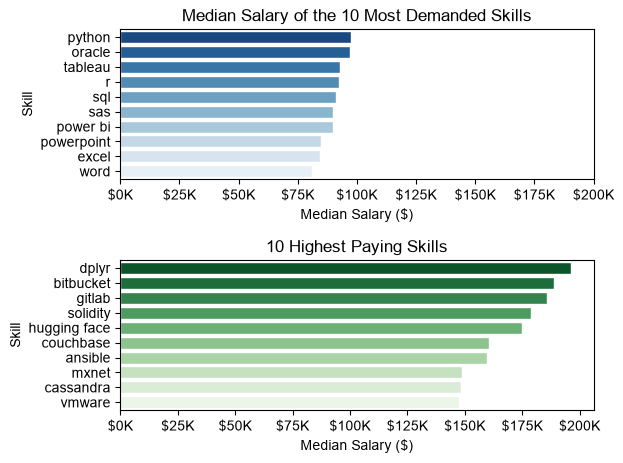

In [7]:

fig, ax = plt.subplots(2, 1)
sns.set_theme(style = 'ticks')
Needed = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
Needed = Needed.explode('job_skills')

Demand = Needed.dropna(subset=['job_skills']).groupby('job_skills').size().sort_values(ascending=False).head(10)

DemandSalary = Needed.dropna(subset=['job_skills']).groupby('job_skills')['salary_year_avg'].median().loc[Demand.index].sort_values(ascending=False)

sns.barplot(x=DemandSalary.values, y=DemandSalary.index, ax=ax[0], hue=DemandSalary.index, palette='Blues_r', legend=False)

ax[0].set_title('Median Salary of the 10 Most Demanded Skills')
ax[0].set_xlabel('Median Salary ($)')
ax[0].set_ylabel('Skill')
ax[0].set_xlim(0, 200000)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

Pay = Needed.dropna(subset=['job_skills']).groupby('job_skills')['salary_year_avg'].median().sort_values(ascending=False).head(10)

sns.barplot(x=Pay.values, y=Pay.index, ax=ax[1], hue=Pay.index, palette='Greens_r', legend=False)

ax[1].set_title('10 Highest Paying Skills')
ax[1].set_xlabel('Median Salary ($)')
ax[1].set_ylabel('Skill')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt.show()

